# Step 2 — DANN: Domain-Adversarial Neural Network

**Why DANN after MMD-Net?**  
MMD-Net (step1) got target macro-F1 = 0.194. The MMD penalty plateaued at ~0.094 throughout training — the kernel was insensitive and class loss dominated, causing source overfit (99.8% source accuracy). DANN replaces the explicit distribution metric with an adversarial game: a domain discriminator tries to tell source from target, and a Gradient Reversal Layer (GRL) forces the encoder to produce features that fool it — making representations domain-invariant by design.

**Prior art (improvements/3_domain_adaptation):** best target F1 = **0.379** at 50 epochs with grl_lambda=0.2, domain_weight=0.1, lr=2e-4. Runs at 100 epochs degraded to 0.123 (source overfit). This notebook uses those hyperparams plus a DANN lambda schedule and in-memory CORAL pre-alignment.

```
X_src ──┐
        ├──► Encoder (3000→128) ──► Label Predictor (→6)   [CE loss, source only]
X_tgt ──┘         │
                  └──► GRL(λ) ──► Domain Disc (→1)         [BCE loss, both domains]
```

In [9]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step2_dann' else Path.cwd()
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF version:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF version: 2.21.0


## 1. Data Loading + CORAL Pre-Alignment

CORAL (CORrelation ALignment) matches the covariance of target features to source features before training. This gives the encoder a cleaner starting point — the batch correction report showed CORAL reduced batch separation from 0.999 → 0.901, the best of all methods tested. The corrected `.npy` was never saved to disk, so we compute it in-memory here.

In [10]:
# Load source splits
X_train_src = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train_src = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test_src  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test_src  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

# Load target (unlabeled for training, labeled subset for evaluation)
X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes = len(class_names)

# Load labeled target subset for evaluation only
labels_csv = PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv'
df_labels = pd.read_csv(labels_csv)
mask = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
X_target_eval = X_target_raw[mask.values]
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

print(f'Source train:  {X_train_src.shape}, classes: {n_classes}')
print(f'Source test:   {X_test_src.shape}')
print(f'Target total:  {X_target_raw.shape}')
print(f'Target eval:   {X_target_eval.shape}')
print(f'Classes: {class_names}')

Source train:  (6824, 3000), classes: 6
Source test:   (1706, 3000)
Target total:  (63877, 3000)
Target eval:   (12776, 3000)
Classes: ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']


In [11]:
def coral_align(X_src, X_tgt, reg=1e-3):
    """Align target covariance to source covariance (CORAL)."""
    # Center
    src_mean = X_src.mean(axis=0)
    tgt_mean = X_tgt.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - tgt_mean

    # Covariance matrices with regularization
    n_s, n_t = Xs.shape[0], Xt.shape[0]
    Cs = (Xs.T @ Xs) / (n_s - 1) + reg * np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (n_t - 1) + reg * np.eye(Xt.shape[1])

    # Matrix square roots via eigen-decomposition
    def mat_sqrt(M):
        vals, vecs = np.linalg.eigh(M)
        vals = np.maximum(vals, 0)
        return vecs @ np.diag(np.sqrt(vals)) @ vecs.T

    def mat_inv_sqrt(M):
        vals, vecs = np.linalg.eigh(M)
        vals = np.maximum(vals, 1e-10)
        return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

    W = mat_inv_sqrt(Ct) @ mat_sqrt(Cs)
    X_tgt_aligned = (Xt @ W) + src_mean
    return X_tgt_aligned.astype(np.float32)

print('Computing CORAL alignment (may take ~30s for 3000 dims)...')
X_target_coral = coral_align(X_train_src, X_target_raw)
X_target_eval_coral = X_target_coral[mask.values]
print(f'CORAL-aligned target: {X_target_coral.shape}')

Computing CORAL alignment (may take ~30s for 3000 dims)...
CORAL-aligned target: (63877, 3000)


## 2. Gradient Reversal Layer + DANN Model

In [12]:
class GradientReversalLayer(keras.layers.Layer):
    """Identity on forward pass; negates and scales gradients on backward pass."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.lambda_val = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    def call(self, x):
        lam = self.lambda_val
        @tf.custom_gradient
        def _reverse(x):
            return x, lambda dy: -lam * dy
        return _reverse(x)

    def get_config(self):
        return super().get_config()


def build_encoder(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    return keras.Model(inp, x, name='encoder')


def build_label_predictor(latent_dim, n_classes):
    inp = keras.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='label_predictor')


def build_domain_discriminator(latent_dim):
    inp = keras.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(inp)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='domain_discriminator')


print('Layers defined.')

Layers defined.


In [13]:
class DANNModel(keras.Model):
    def __init__(self, encoder, label_predictor, domain_discriminator, grl, domain_loss_weight=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.label_predictor = label_predictor
        self.domain_discriminator = domain_discriminator
        self.grl = grl
        self.domain_loss_weight = domain_loss_weight

        self.total_loss_tracker   = keras.metrics.Mean(name='loss')
        self.class_loss_tracker   = keras.metrics.Mean(name='class_loss')
        self.domain_loss_tracker  = keras.metrics.Mean(name='domain_loss')
        self.class_acc_tracker    = keras.metrics.SparseCategoricalAccuracy(name='class_acc')
        self.domain_acc_tracker   = keras.metrics.BinaryAccuracy(name='domain_acc')

    def call(self, inputs, training=False):
        z = self.encoder(inputs, training=training)
        return self.label_predictor(z, training=training)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data
        batch = tf.shape(src_x)[0]

        # Domain labels: 0 = source, 1 = target
        d_src = tf.zeros((batch, 1), dtype=tf.float32)
        d_tgt = tf.ones((batch, 1), dtype=tf.float32)

        with tf.GradientTape() as tape:
            z_src = self.encoder(src_x, training=True)
            z_tgt = self.encoder(tgt_x, training=True)

            # Classification loss (source only)
            y_pred = self.label_predictor(z_src, training=True)
            class_loss = tf.reduce_mean(
                keras.losses.sparse_categorical_crossentropy(src_y, y_pred)
            )

            # Domain loss (both domains through GRL)
            z_src_rev = self.grl(z_src)
            z_tgt_rev = self.grl(z_tgt)
            d_pred_src = self.domain_discriminator(z_src_rev, training=True)
            d_pred_tgt = self.domain_discriminator(z_tgt_rev, training=True)
            domain_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(d_src, d_pred_src)
            ) + tf.reduce_mean(
                keras.losses.binary_crossentropy(d_tgt, d_pred_tgt)
            )

            total_loss = class_loss + self.domain_loss_weight * domain_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        d_both = tf.concat([d_src, d_tgt], axis=0)
        d_pred_both = tf.concat([d_pred_src, d_pred_tgt], axis=0)

        self.total_loss_tracker.update_state(total_loss)
        self.class_loss_tracker.update_state(class_loss)
        self.domain_loss_tracker.update_state(domain_loss)
        self.class_acc_tracker.update_state(src_y, y_pred)
        self.domain_acc_tracker.update_state(d_both, d_pred_both)

        return {
            'loss': self.total_loss_tracker.result(),
            'class_loss': self.class_loss_tracker.result(),
            'domain_loss': self.domain_loss_tracker.result(),
            'class_acc': self.class_acc_tracker.result(),
            'domain_acc': self.domain_acc_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        z = self.encoder(x, training=False)
        y_pred = self.label_predictor(z, training=False)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, y_pred))
        self.class_loss_tracker.update_state(loss)
        self.class_acc_tracker.update_state(y, y_pred)
        return {'class_loss': self.class_loss_tracker.result(), 'class_acc': self.class_acc_tracker.result()}

    @property
    def metrics(self):
        return [
            self.total_loss_tracker, self.class_loss_tracker,
            self.domain_loss_tracker, self.class_acc_tracker, self.domain_acc_tracker
        ]

print('DANNModel class defined.')

DANNModel class defined.


## 3. Model Instantiation + Datasets

In [14]:
BATCH_SIZE = 128
LEARNING_RATE = 2e-4
DOMAIN_LOSS_WEIGHT = 0.1
MAX_EPOCHS = 100
PATIENCE = 15

grl = GradientReversalLayer(name='grl')
encoder          = build_encoder(X_train_src.shape[1])
label_predictor  = build_label_predictor(128, n_classes)
domain_disc      = build_domain_discriminator(128)

dann = DANNModel(
    encoder=encoder,
    label_predictor=label_predictor,
    domain_discriminator=domain_disc,
    grl=grl,
    domain_loss_weight=DOMAIN_LOSS_WEIGHT,
    name='dann'
)
dann.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE))

# Source dataset (labeled)
src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_src, y_train_src))
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
)

# Target dataset (unlabeled — CORAL aligned)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
    .repeat()
)

train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))

# Validation: source test set (standard Keras format)
val_ds = tf.data.Dataset.from_tensor_slices((X_test_src, y_test_src)).batch(BATCH_SIZE)

encoder.summary()
print(f'\nSteps per epoch: {len(src_ds)}')

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 3000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     1,536,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 512)            │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,272 (6.49 MB)

 Trainable params: 1,702,272 (6.49 MB)

 Non-trainable params: 0 (0.00 B)


Steps per epoch: 53


## 4. Lambda Schedule Callback

The DANN paper ramps λ from 0 → 1 using `λ(p) = 2/(1+e^{−10p})−1` where `p = epoch/total_epochs`. This lets the classifier stabilize in early epochs before adversarial pressure grows.

In [15]:
class DANNLambdaScheduler(keras.callbacks.Callback):
    def __init__(self, grl_layer, total_epochs):
        super().__init__()
        self.grl = grl_layer
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        p = epoch / self.total_epochs
        lam = 2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0
        self.grl.lambda_val.assign(lam)

    def on_epoch_end(self, epoch, logs=None):
        lam = float(self.grl.lambda_val.numpy())
        if (epoch + 1) % 10 == 0:
            print(f'  [λ={lam:.3f}]', end='')


callbacks = [
    DANNLambdaScheduler(grl, MAX_EPOCHS),
    keras.callbacks.EarlyStopping(
        monitor='val_class_loss',
        mode='min',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_class_loss',
        mode='min',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
]
print('Callbacks ready.')

Callbacks ready.


## 5. Training

In [16]:
history = dann.fit(
    train_ds,
    epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - class_acc: 0.4397 - class_loss: 1.4578 - domain_acc: 0.4966 - domain_loss: 1.7022 - loss: 1.6280 - val_class_acc: 0.7093 - val_class_loss: 0.7872 - learning_rate: 2.0000e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - class_acc: 0.7528 - class_loss: 0.6878 - domain_acc: 0.5077 - domain_loss: 1.5024 - loss: 0.8380 - val_class_acc: 0.8136 - val_class_loss: 0.5107 - learning_rate: 2.0000e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - class_acc: 0.8527 - class_loss: 0.4223 - domain_acc: 0.5221 - domain_loss: 1.4463 - loss: 0.5670 - val_class_acc: 0.8482 - val_class_loss: 0.4143 - learning_rate: 2.0000e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - class_acc: 0.9132 - class_loss: 0.2640 - domain_acc: 0.5507 - domain_loss: 1.4016 - loss: 0.4042 - val_class_acc: 0.8634 - val_class_loss: 0.3867 - learning_rate: 2.0000e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - class_acc: 0.9465 - class_loss: 0.167

## 6. Training Curves

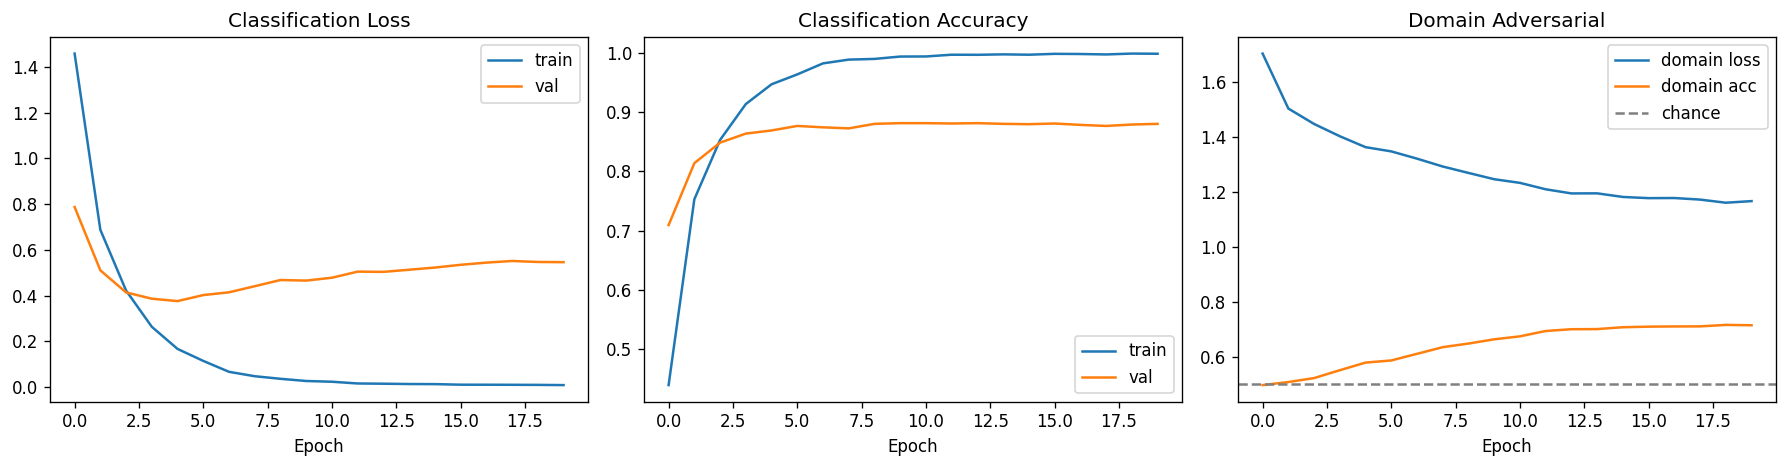

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['class_loss'], label='train')
axes[0].plot(history.history['val_class_loss'], label='val')
axes[0].set_title('Classification Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['class_acc'], label='train')
axes[1].plot(history.history['val_class_acc'], label='val')
axes[1].set_title('Classification Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['domain_loss'], label='domain loss')
axes[2].plot(history.history['domain_acc'], label='domain acc')
axes[2].axhline(0.5, color='gray', linestyle='--', label='chance')
axes[2].set_title('Domain Adversarial')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

## 7. Evaluation — Source Test Set

In [18]:
y_pred_src_probs = dann.predict(X_test_src, batch_size=BATCH_SIZE)
y_pred_src = np.argmax(y_pred_src_probs, axis=1)

src_f1 = f1_score(y_test_src, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test_src, y_pred_src, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Source Test Macro F1: 0.8516
              precision    recall  f1-score   support

    Effector       0.89      0.95      0.92       482
   Exhausted       0.89      0.93      0.91       166
       Naive       0.81      0.82      0.82       224
   Other_CD4       0.80      0.77      0.78       321
    Th1-like       0.85      0.68      0.76       141
        Treg       0.94      0.93      0.93       372

    accuracy                           0.87      1706
   macro avg       0.86      0.85      0.85      1706
weighted avg       0.87      0.87      0.87      1706



## 8. Evaluation — Target Domain (CORAL-aligned)

In [19]:
y_pred_tgt_probs = dann.predict(X_target_eval_coral, batch_size=BATCH_SIZE)
y_pred_tgt = np.argmax(y_pred_tgt_probs, axis=1)

tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Macro F1 (CORAL-aligned): {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Target Macro F1 (CORAL-aligned): 0.3910
              precision    recall  f1-score   support

    Effector       0.53      0.58      0.56      2839
   Exhausted       0.08      0.10      0.08       903
       Naive       0.86      0.48      0.62      3806
   Other_CD4       0.37      0.35      0.36      2127
    Th1-like       0.18      0.20      0.19      1031
        Treg       0.44      0.69      0.54      2070

    accuracy                           0.47     12776
   macro avg       0.41      0.40      0.39     12776
weighted avg       0.53      0.47      0.48     12776



## 9. Confusion Matrices

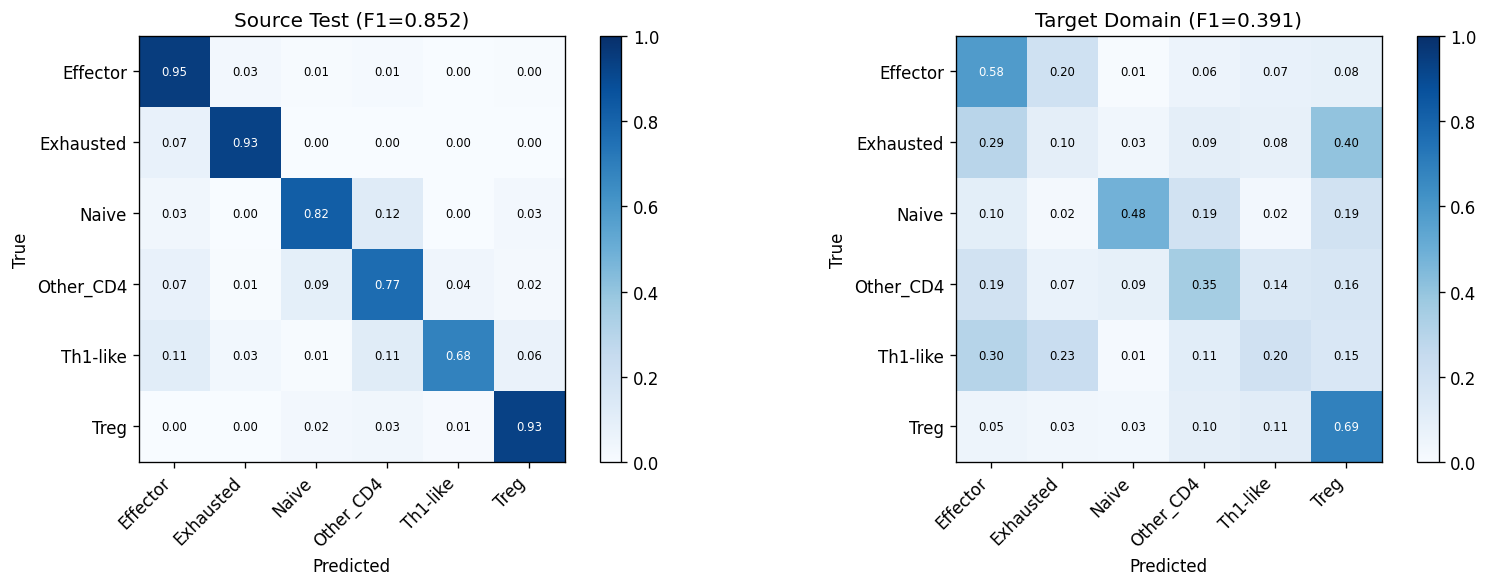

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_test_src, y_pred_src, f'Source Test (F1={src_f1:.3f})'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain (F1={tgt_f1:.3f})'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i, j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10. Save Results + Model

In [21]:
from sklearn.metrics import accuracy_score

src_report = classification_report(y_test_src, y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'DANN',
    'config': {
        'encoder_dims': [512, 256, 128],
        'domain_loss_weight': DOMAIN_LOSS_WEIGHT,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history.history['loss']),
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'coral_aligned': True,
    },
    'source_test': {
        'macro_f1': src_f1,
        'accuracy': accuracy_score(y_test_src, y_pred_src),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1': tgt_f1,
        'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
    'training_history': {
        'class_loss': history.history['class_loss'],
        'val_class_loss': history.history['val_class_loss'],
        'class_acc': history.history['class_acc'],
        'domain_acc': history.history['domain_acc'],
    }
}

with open(RESULTS_DIR / 'dann_results.json', 'w') as f:
    json.dump(results, f, indent=2)

dann.encoder.save(str(RESULTS_DIR / 'dann_encoder.keras'))
dann.label_predictor.save(str(RESULTS_DIR / 'dann_label_predictor.keras'))

print(f'\n=== DANN Summary ===')
print(f'Source Test  Macro F1 : {src_f1:.4f}')
print(f'Target Domain Macro F1: {tgt_f1:.4f}')
print(f'Epochs trained        : {len(history.history["loss"])}')
print(f'Results saved to      : {RESULTS_DIR.resolve()}')


=== DANN Summary ===
Source Test  Macro F1 : 0.8516
Target Domain Macro F1: 0.3910
Epochs trained        : 20
Results saved to      : /Users/kirtan/Projects /NNDL/experiments/step2_dann/results
